# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [98]:
from functions import *

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [99]:
data = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')
data.head()

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Marital_Married,Marital_Single,Location__0,Location__1,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,1,0,0,1,0,0,0,0,0,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,1,0,0,0,0,0,0,1,0,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,1,0,0,0,0,1,0,0,0,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0


## Behavioral segmentation

In [100]:
behavioral_data = data[["PctFlightsWithCompanions", "PctPointsSpent",
                        
                        "Pct_Spend_Month_1", "Pct_Spend_Month_2", "Pct_Spend_Month_3", "Pct_Spend_Month_4", "Pct_Spend_Month_5", 
                        "Pct_Spend_Month_6", "Pct_Spend_Month_7", "Pct_Spend_Month_8", "Pct_Spend_Month_9", "Pct_Spend_Month_10", 
                        "Pct_Spend_Month_11", "Pct_Spend_Month_12"]]

Total Spends per month will not be used as they become redundant when gathered with the percentages per month.

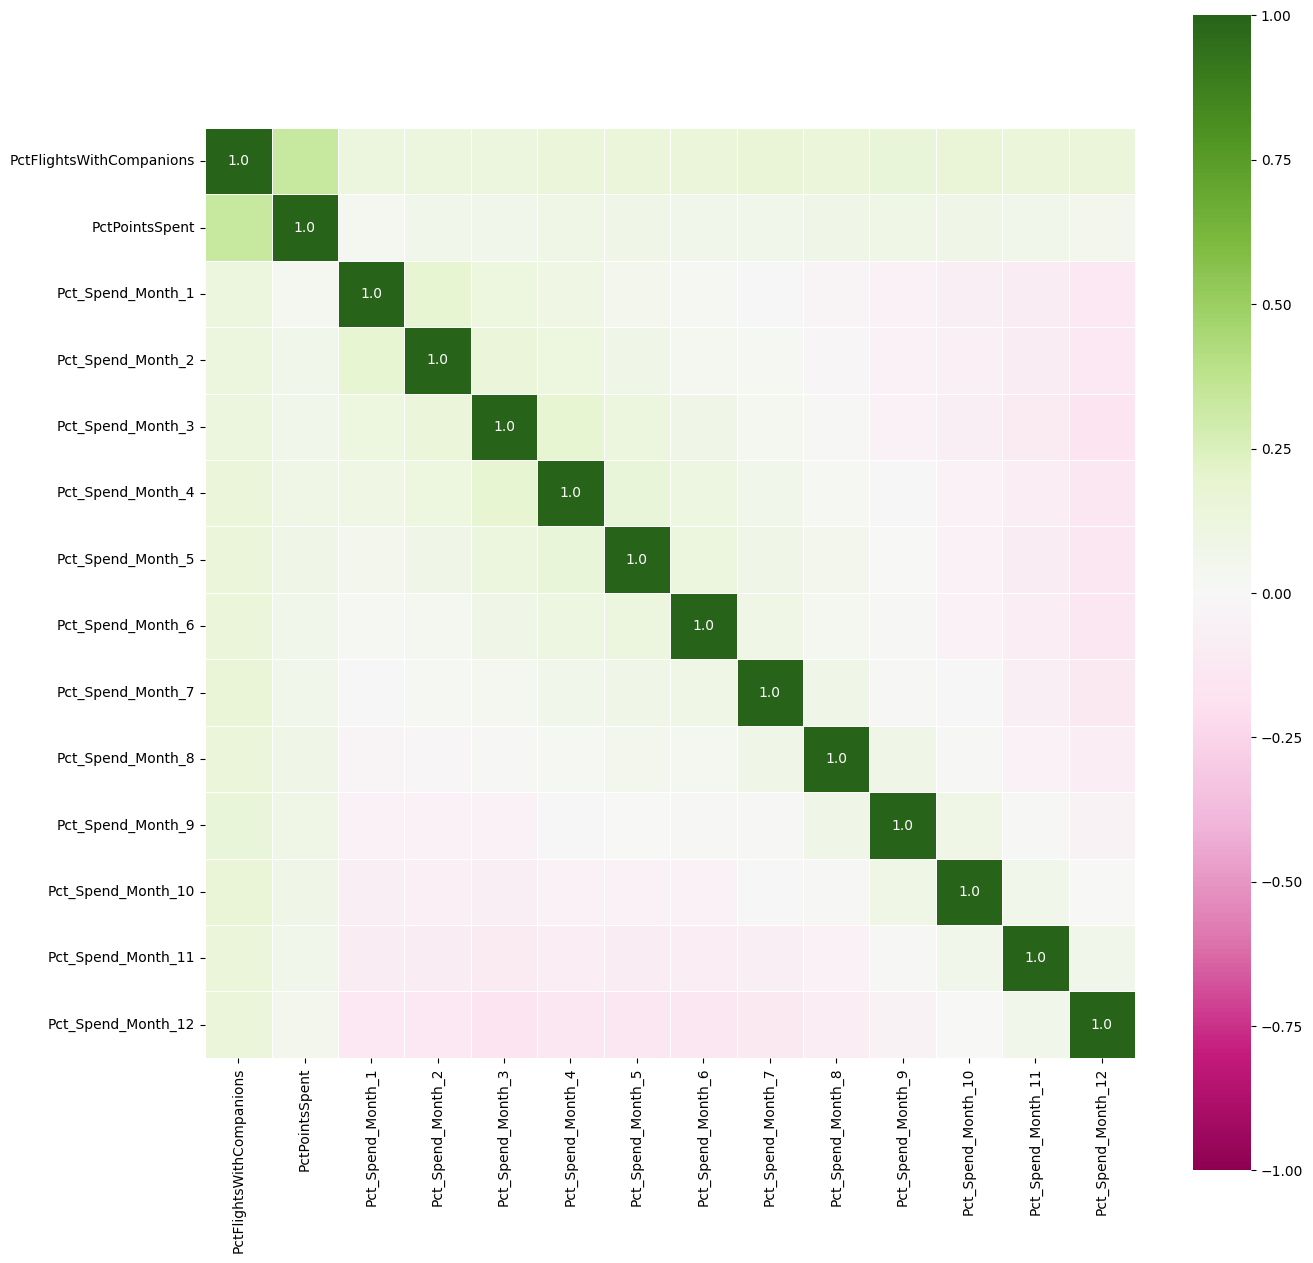

In [101]:
correlation_matrix(behavioral_data, 0.7, 15, 15)

It doesn't exist any high correlation between features, so all features will be kept.

In [102]:
behavioral_data.to_csv("../data/clustering_data/behavioral_data.csv")

In [103]:
behavioral_data = behavioral_data.copy()

In [104]:
behavioral_data

,PctFlightsWithCompanions,PctPointsSpent,Pct_Spend_Month_1,Pct_Spend_Month_2,Pct_Spend_Month_3,Pct_Spend_Month_4,Pct_Spend_Month_5,Pct_Spend_Month_6,Pct_Spend_Month_7,Pct_Spend_Month_8,Pct_Spend_Month_9,Pct_Spend_Month_10,Pct_Spend_Month_11,Pct_Spend_Month_12
Loyalty#,,,,,,,,,,,,,,
100011,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100012,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100013,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100014,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100015,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
999996,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
999997,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695


In [105]:
behavioral_data_st_scl = StandardScaler().fit_transform(behavioral_data)
behavioral_data_mm_scl = MinMaxScaler().fit_transform(behavioral_data)
behavioral_data_rb_scl = RobustScaler().fit_transform(behavioral_data)

# <span style="color:#0097b2">1. Modelling</span>
[Back to TOC](#toc)

### Behavioral Data

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

### K-Means

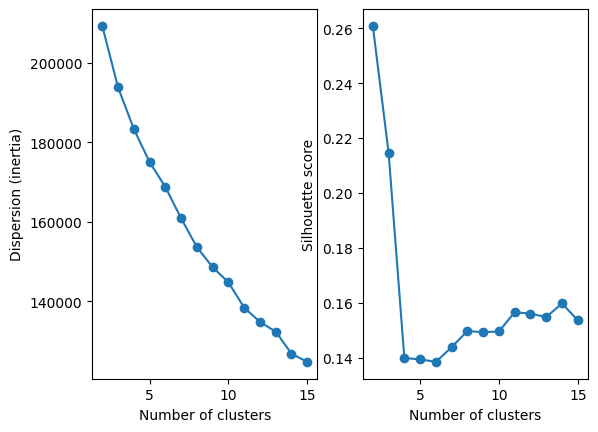

In [106]:
plot_inertia_and_silhouette(behavioral_data_st_scl)

In [107]:
kmeans_st_scl = KMeans(n_clusters=3, random_state=42).fit(behavioral_data_st_scl)
data['st_scaled_km_cluster3'] = kmeans_st_scl.predict(behavioral_data_st_scl)
behavioral_data['st_scaled_km_cluster3'] = kmeans_st_scl.predict(behavioral_data_st_scl)

### Hierarchichal - Ward

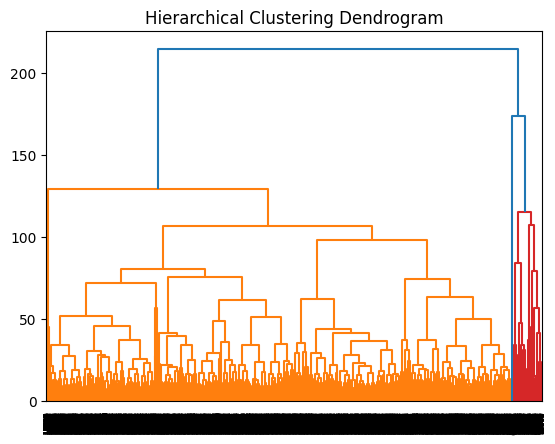

In [108]:
plot_dendrogram(behavioral_data_st_scl, 'ward')

In [109]:
data['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_st_scl)

behavioral_data['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_st_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">MinMax Scaling</h3>

### K-Means

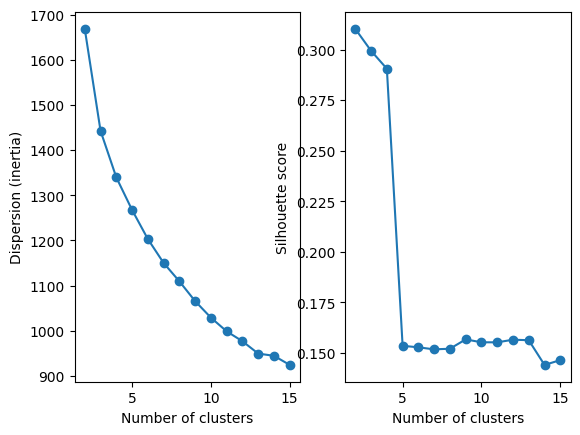

In [110]:
plot_inertia_and_silhouette(behavioral_data_mm_scl)

In [111]:
kmeans_mm_scl = KMeans(n_clusters=3, random_state=42).fit(behavioral_data_mm_scl)
data['mm_scaled_km_cluster3'] = kmeans_mm_scl.predict(behavioral_data_mm_scl)
behavioral_data['mm_scaled_km_cluster3'] = kmeans_mm_scl.predict(behavioral_data_mm_scl)

### Hierarchichal - Ward

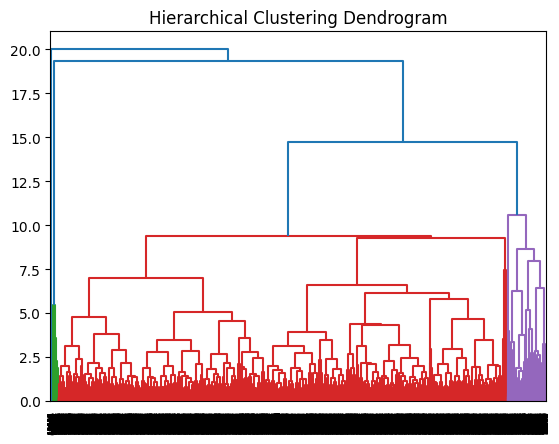

In [112]:
plot_dendrogram(behavioral_data_mm_scl, 'ward')

In [113]:
data['mm_scaled_ward_cluster4'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 4
    ).fit_predict(behavioral_data_mm_scl)

behavioral_data['mm_scaled_ward_cluster4'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 4
    ).fit_predict(behavioral_data_mm_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

### K-Means

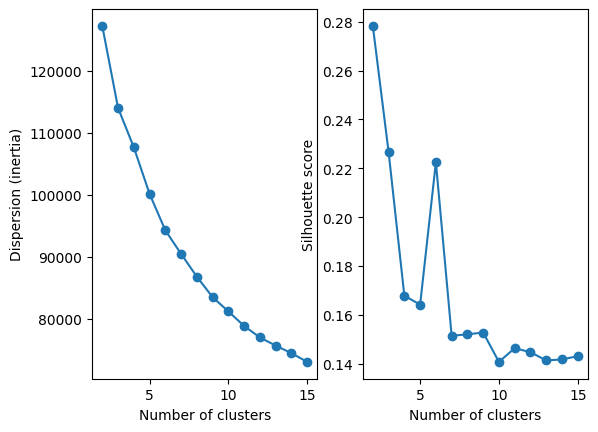

In [114]:
plot_inertia_and_silhouette(behavioral_data_rb_scl)

In [115]:
kmeans_rb_scl = KMeans(n_clusters=4, random_state=42).fit(behavioral_data_rb_scl)
data['rb_scaled_km_cluster4'] = kmeans_rb_scl.predict(behavioral_data_rb_scl)
behavioral_data['rb_scaled_km_cluster4'] = kmeans_rb_scl.predict(behavioral_data_rb_scl)

### Hierarchichal - Ward

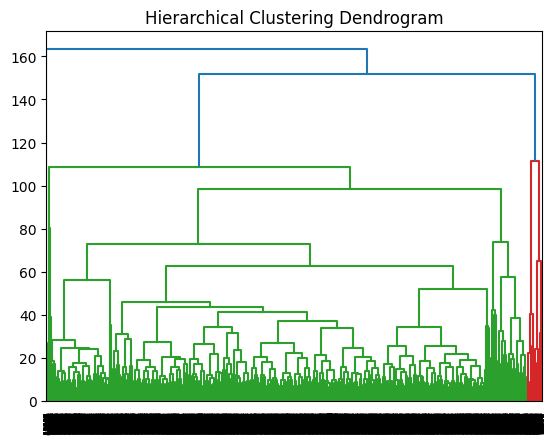

In [116]:
plot_dendrogram(behavioral_data_rb_scl, 'ward')

In [117]:
data['rb_scaled_ward_cluster5'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 5
    ).fit_predict(behavioral_data_rb_scl)

behavioral_data['rb_scaled_ward_cluster5'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 5
    ).fit_predict(behavioral_data_rb_scl)

# <span style="color:#0097b2">1. Filtering</span>
[Back to TOC](#toc)

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(1) First-Examination</h3>

#### Cluster Visualization 1

In [118]:
clusters_km = ['st_scaled_km_cluster3', 'st_scaled_ward_cluster2',
               'mm_scaled_km_cluster3', 'mm_scaled_ward_cluster4',
               'rb_scaled_km_cluster4', 'rb_scaled_ward_cluster5']

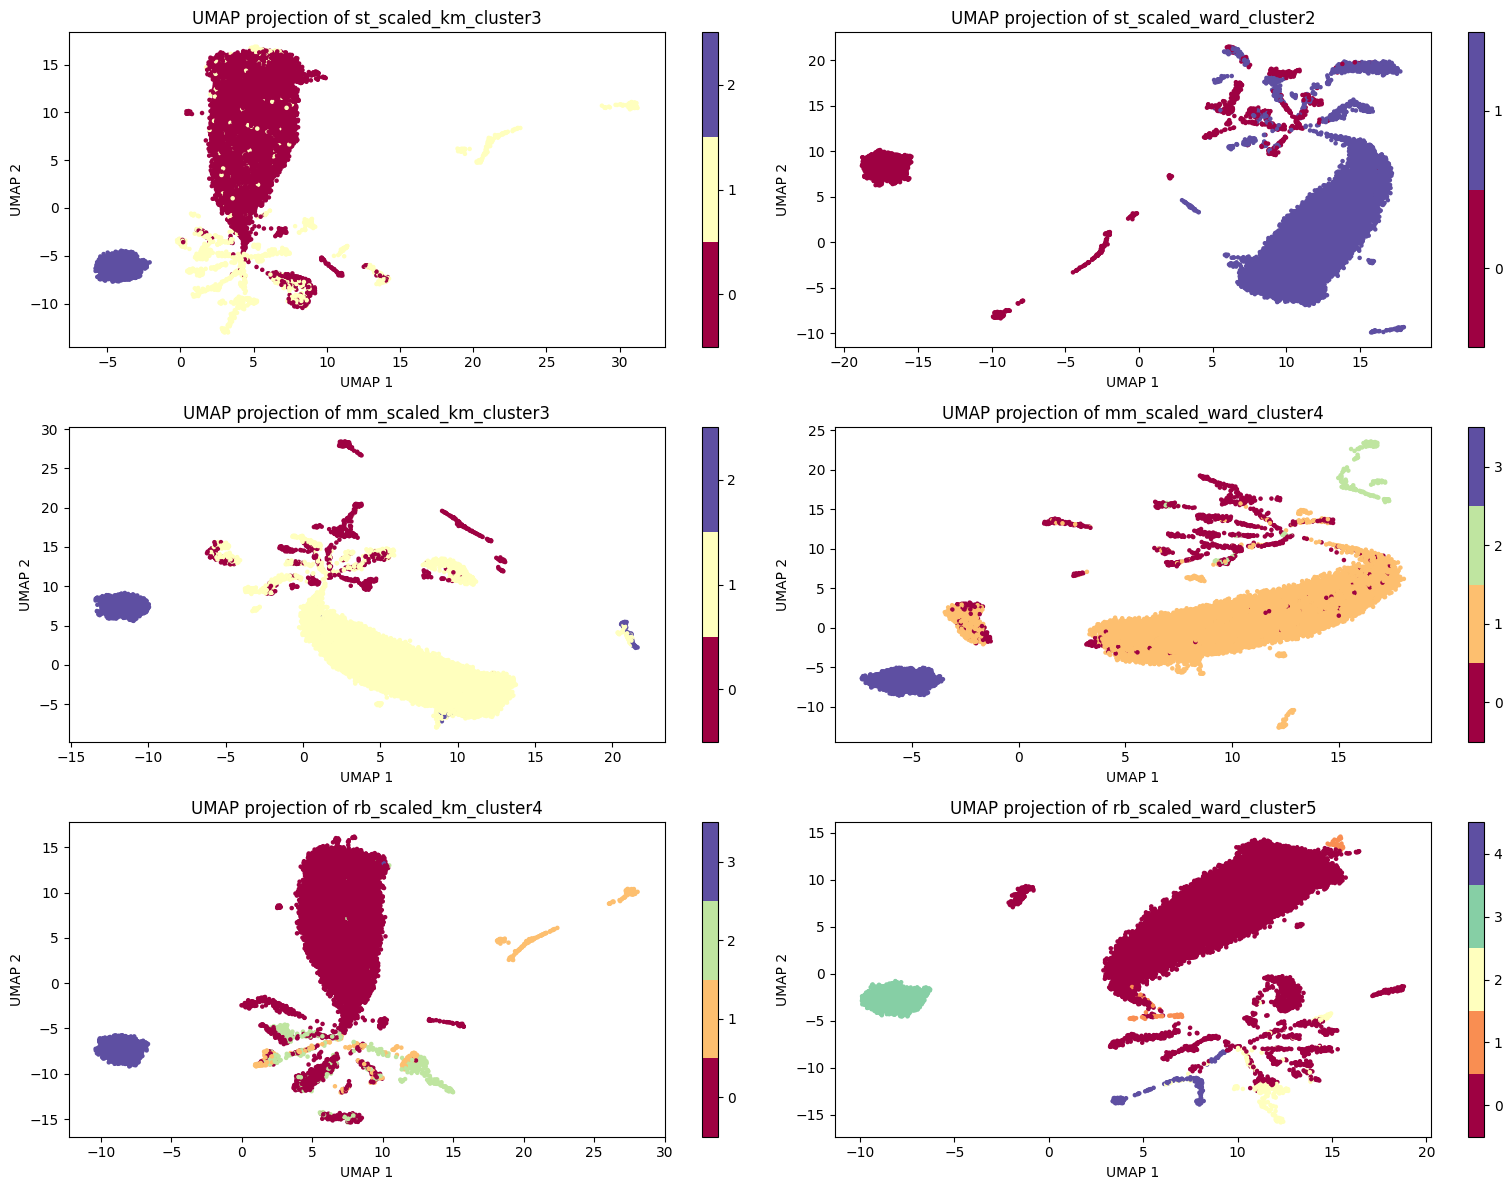

In [119]:
plot_umap_projections(behavioral_data, clusters_km, n_neighbors= 40, min_dist= 0.8)

In [120]:
groupby_mean(behavioral_data, 'mm_scaled_ward_cluster4', n_features= 13)

mm_scaled_ward_cluster4,0,1,2,3
PctFlightsWithCompanions,0.269118,0.252386,0.290615,0.0
PctPointsSpent,0.358129,0.301117,0.342475,0.0
Pct_Spend_Month_1,0.011889,0.064119,0.000242,0.0
Pct_Spend_Month_2,0.015067,0.062156,0.000060,0.0
Pct_Spend_Month_3,0.018362,0.081090,0.000000,0.0
Pct_Spend_Month_4,0.014648,0.071120,0.000050,0.0
Pct_Spend_Month_5,0.017508,0.084146,0.000000,0.0
Pct_Spend_Month_6,0.016970,0.104595,0.000000,0.0
Pct_Spend_Month_7,0.020288,0.110118,0.002581,0.0
Pct_Spend_Month_8,0.092852,0.097611,0.004676,0.0


- Cluster 3 - No Activity Customers

#### Cluster Extraction 1

Now, we'll save the cluster.

In [121]:
# Filter the DataFrame based on cluster labels
no_activity = data[data['mm_scaled_ward_cluster4'] == 3]

In [122]:
no_activity

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__4,Location__5,Location__6,Location__7,st_scaled_km_cluster3,st_scaled_ward_cluster2,mm_scaled_km_cluster3,mm_scaled_ward_cluster4,rb_scaled_km_cluster4,rb_scaled_ward_cluster5
Loyalty#,,,,,,,,,,,,,,,,,,,,,
101356,25666.0,7482.64,0,0,2228.0,0,2015,11,0.0,0.0,...,0,0,0,0,2,0,2,3,3,3
102308,0.0,12866.89,0,0,44.0,0,2021,11,0.0,0.0,...,1,0,0,0,2,0,2,3,3,3
103352,51705.0,5555.49,0,0,281.0,1,2017,11,0.0,0.0,...,1,0,0,0,2,0,2,3,3,3
103383,11432.0,13466.92,0,0,245.0,1,2018,6,0.0,0.0,...,0,0,0,0,2,0,2,3,3,3
104739,22520.0,5498.94,0,0,232.0,1,2016,11,0.0,0.0,...,1,0,0,0,2,0,2,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997857,30817.0,3436.13,0,0,41.0,1,2019,6,0.0,0.0,...,0,0,0,0,2,0,2,3,3,3
997912,22828.0,16473.17,0,0,98.0,1,2016,8,0.0,0.0,...,1,0,0,0,2,0,2,3,3,3
999143,36305.0,4861.37,0,0,243.0,1,2018,7,0.0,0.0,...,0,0,0,0,2,0,2,3,3,3


To proceed looking for the other cluster, we'll remove the one already found from the data.

In [123]:
# List of cluster labels to exclude
exclude_clusters = [3]

# Filter the original dataset to exclude rows with specified cluster labels
data_filtered1 = data[~data['mm_scaled_ward_cluster4'].isin(exclude_clusters)]

In [124]:
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__4,Location__5,Location__6,Location__7,st_scaled_km_cluster3,st_scaled_ward_cluster2,mm_scaled_km_cluster3,mm_scaled_ward_cluster4,rb_scaled_km_cluster4,rb_scaled_ward_cluster5
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,0,1,1,1,0,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,1,0,0,0,0,1,1,1,0,0
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,1,0,0,0,1,1,1,0,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,0,0,0,0,0,1,1,1,0,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,1,0,0,0,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,1,0,0,0,0,1,1,1,0,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,0,1,1,1,0,0
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,0,0,0,0,0,1,1,1,0,0


Now, we'll remove the cluster columns from the dataset with all the data and the one with the behavioral data.

In [125]:
data_filtered1 = data_filtered1.iloc[:, :-6]
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Marital_Married,Marital_Single,Location__0,Location__1,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,1,0,0,1,0,0,0,0,0,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,1,0,0,0,0,0,0,1,0,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,1,0,0,0,0,1,0,0,0,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,1,0,1,0,0,0,0,0,0
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,1,0,0,0,0,1,0,0,0,0


In [126]:
behavioral_data = behavioral_data.iloc[:, :-6]
behavioral_data

,PctFlightsWithCompanions,PctPointsSpent,Pct_Spend_Month_1,Pct_Spend_Month_2,Pct_Spend_Month_3,Pct_Spend_Month_4,Pct_Spend_Month_5,Pct_Spend_Month_6,Pct_Spend_Month_7,Pct_Spend_Month_8,Pct_Spend_Month_9,Pct_Spend_Month_10,Pct_Spend_Month_11,Pct_Spend_Month_12
Loyalty#,,,,,,,,,,,,,,
100011,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100012,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100013,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100014,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100015,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
999996,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
999997,0.234242,0.215097,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695


### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(2) Second-Examination</h3>

In [127]:
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Marital_Married,Marital_Single,Location__0,Location__1,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,1,0,0,1,0,0,0,0,0,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,1,0,0,0,0,0,0,1,0,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,1,0,0,0,0,1,0,0,0,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,1,0,1,0,0,0,0,0,0
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,1,0,0,0,0,1,0,0,0,0


Next, we are creating the behavioral data again, but from the data with the cluster identified already removed.

In [128]:
data_filtered11 = data_filtered1.copy()
behavioral_data_1 = data_filtered11[behavioral_data.columns.to_list()]

And now we'll scale again the new behavioral data.

In [ ]:
behavioral_data_1_st_scl = StandardScaler().fit_transform(behavioral_data_1)
behavioral_data_1_mm_scl = MinMaxScaler().fit_transform(behavioral_data_1)
behavioral_data_1_rb_scl = RobustScaler().fit_transform(behavioral_data_1)

#### Cluster Modelling 2

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

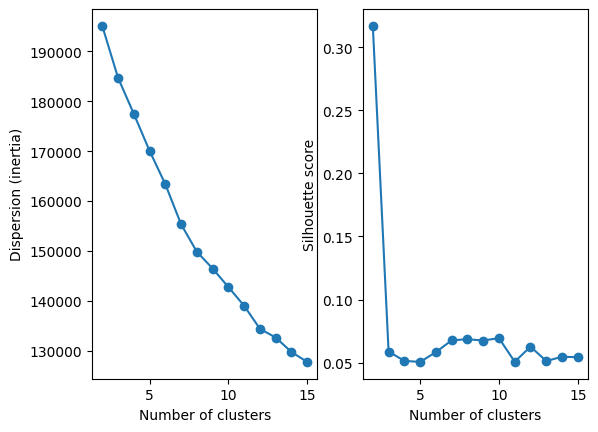

In [130]:
plot_inertia_and_silhouette(behavioral_data_1_st_scl)

In [131]:
kmeans_st_scl = KMeans(n_clusters=2, random_state=42).fit(behavioral_data_1_st_scl)
data_filtered11['st_scaled_km_cluster2'] = kmeans_st_scl.predict(behavioral_data_1_st_scl)
behavioral_data_1['st_scaled_km_cluster2'] = kmeans_st_scl.predict(behavioral_data_1_st_scl)

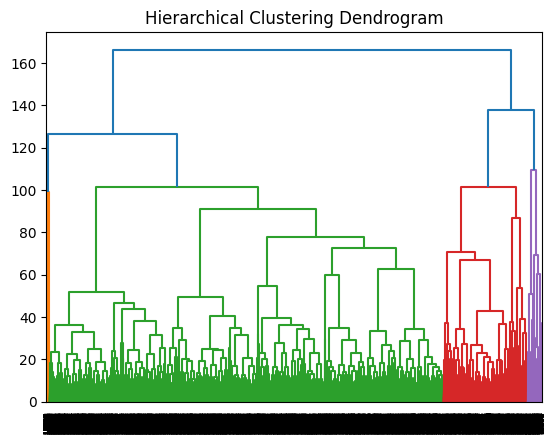

In [132]:
plot_dendrogram(behavioral_data_1_st_scl, 'ward')

In [133]:
data_filtered11['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_st_scl)

behavioral_data_1['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_st_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Min Max Scaling</h3>

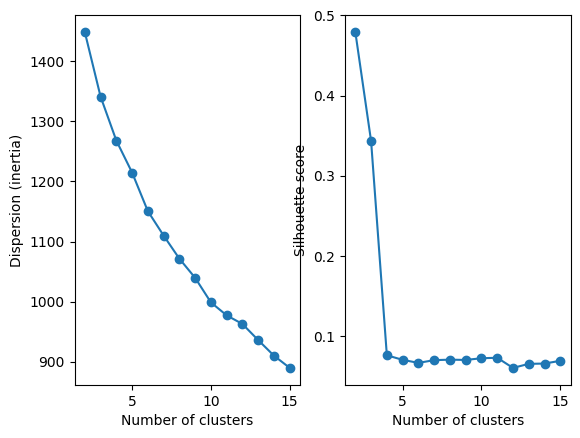

In [134]:
plot_inertia_and_silhouette(behavioral_data_1_mm_scl)

In [135]:
kmeans_mm_scl = KMeans(n_clusters=2, random_state=42).fit(behavioral_data_1_mm_scl)
data_filtered11['mm_scaled_km_cluster2'] = kmeans_mm_scl.predict(behavioral_data_1_mm_scl)
behavioral_data_1['mm_scaled_km_cluster2'] = kmeans_mm_scl.predict(behavioral_data_1_mm_scl)

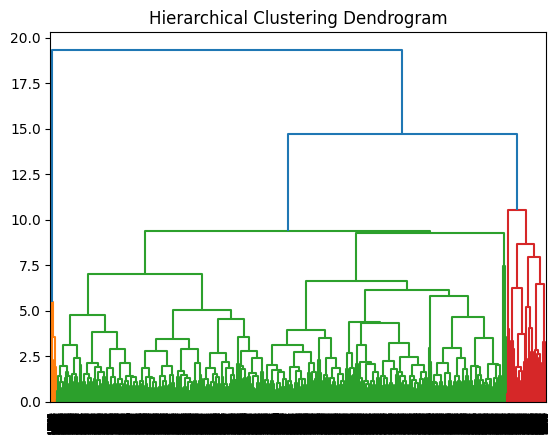

In [136]:
plot_dendrogram(behavioral_data_1_mm_scl, 'ward')

In [137]:
data_filtered11['mm_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_mm_scl)


behavioral_data_1['mm_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_mm_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

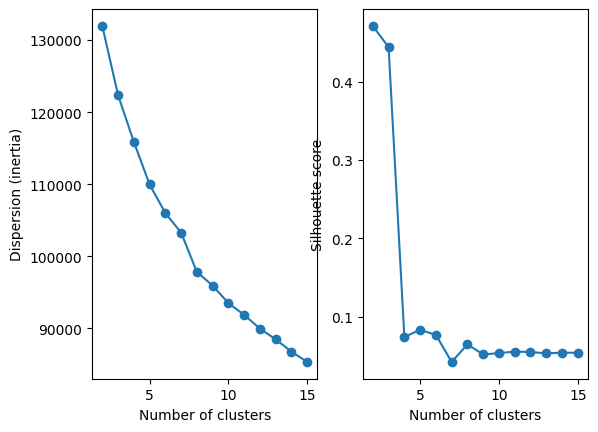

In [138]:
plot_inertia_and_silhouette(behavioral_data_1_rb_scl)

In [139]:
kmeans_rb_scl = KMeans(n_clusters=2, random_state=42).fit(behavioral_data_1_rb_scl)
data_filtered11['rb_scaled_km_cluster2'] = kmeans_rb_scl.predict(behavioral_data_1_rb_scl)
behavioral_data_1['rb_scaled_km_cluster2'] = kmeans_rb_scl.predict(behavioral_data_1_rb_scl)

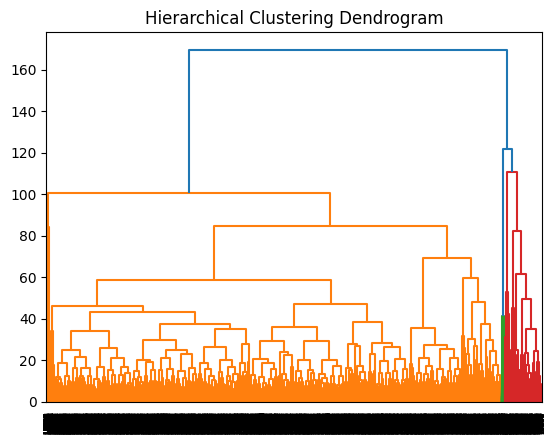

In [140]:
plot_dendrogram(behavioral_data_1_rb_scl, 'ward')

In [141]:
data_filtered11['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_rb_scl)

behavioral_data_1['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_rb_scl)

#### Cluster Visualization 2

In [142]:
cluster_filter1 = ["st_scaled_km_cluster2",	"st_scaled_ward_cluster2", 
                   "mm_scaled_km_cluster2", "mm_scaled_ward_cluster2",
                   "rb_scaled_km_cluster2",	"rb_scaled_ward_cluster2"]

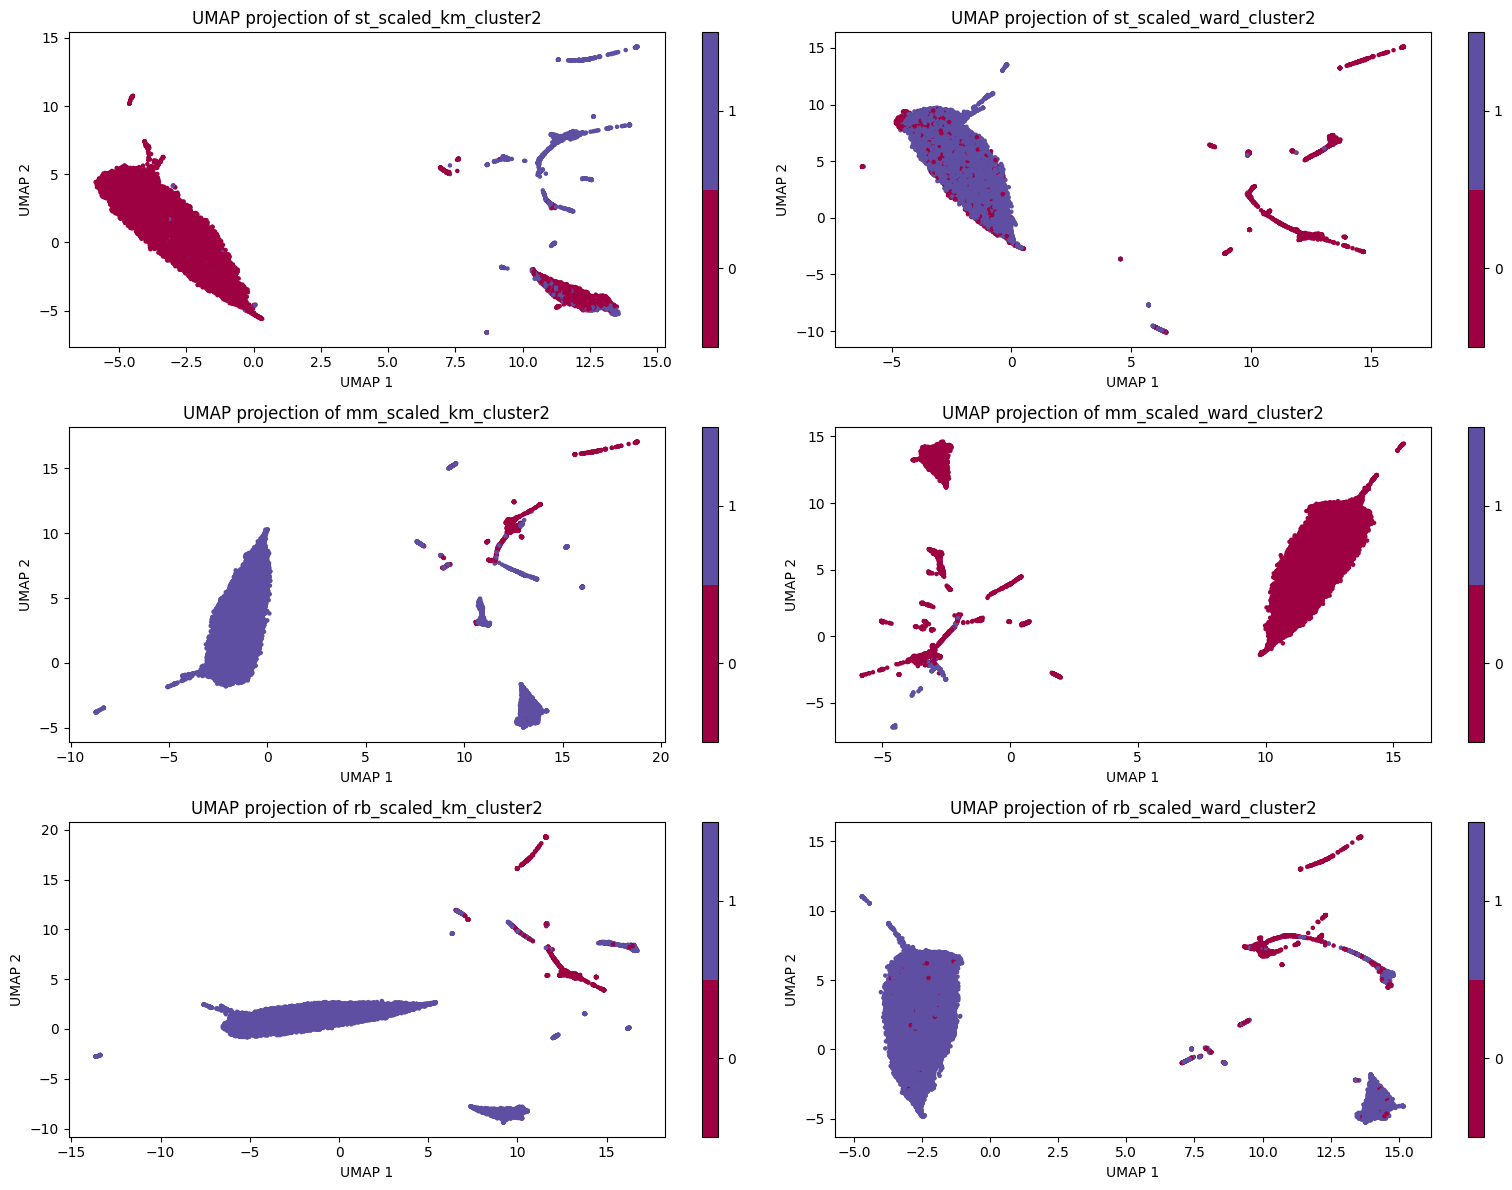

In [143]:
plot_umap_projections(behavioral_data_1, cluster_filter1, n_neighbors= 40, min_dist= 0.1)

In [144]:
groupby_mean(behavioral_data_1, 'st_scaled_ward_cluster2', n_features= 13)

st_scaled_ward_cluster2,0,1
PctFlightsWithCompanions,0.255106,0.254130
PctPointsSpent,0.298790,0.308161
Pct_Spend_Month_1,0.029300,0.066421
Pct_Spend_Month_2,0.025250,0.065524
Pct_Spend_Month_3,0.024462,0.087487
Pct_Spend_Month_4,0.021647,0.076539
Pct_Spend_Month_5,0.029321,0.089642
Pct_Spend_Month_6,0.045702,0.108629
Pct_Spend_Month_7,0.081690,0.106220
Pct_Spend_Month_8,0.111590,0.091735


- Cluster 0 - Fly_from_8_to_12_month ( 75% spent in these months)

#### Cluster Extraction 2

Now, we'll repeat the same steps to remove the cluster and create the new data as we did in the last examination.

In [145]:
# Filter the DataFrame based on cluster labels
_8_to_12_travelers = data_filtered11[data_filtered11['st_scaled_ward_cluster2'] == 0]
len(_8_to_12_travelers)

3056

In [146]:
# List of cluster labels to exclude
exclude_clusters = [0]

# Filter the original dataset to exclude rows with specified cluster labels
data_filter2 = data_filtered11[~data_filtered11['st_scaled_ward_cluster2'].isin(exclude_clusters)]

In [147]:
data_filter2

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__4,Location__5,Location__6,Location__7,st_scaled_km_cluster2,st_scaled_ward_cluster2,mm_scaled_km_cluster2,mm_scaled_ward_cluster2,rb_scaled_km_cluster2,rb_scaled_ward_cluster2
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100102,0.0,2887.74,0,0,2122.0,0,2016,3,247.7,339114.6,...,0,0,0,0,0,1,1,0,1,1
100140,0.0,2838.07,0,0,884.0,0,2019,7,216.8,432030.8,...,0,1,0,0,0,1,1,0,1,1
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,112.3,364601.7,...,0,0,0,0,0,1,1,0,1,1
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,186.4,429630.5,...,0,0,0,0,0,1,1,0,1,1
100301,52499.0,48356.96,0,0,1930.0,0,2016,9,238.6,456142.3,...,0,0,0,0,0,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999631,21104.0,2572.51,0,0,1796.0,0,2017,1,235.3,389557.4,...,0,0,0,0,0,1,1,0,1,1
999731,69600.0,2951.29,0,0,1571.0,1,2016,9,108.3,195054.0,...,0,0,0,0,0,1,1,0,1,1
999891,59732.0,3745.37,0,0,245.0,1,2019,5,1.9,42026.1,...,0,0,0,0,0,1,1,0,1,1


In [148]:
data_filter2 = data_filter2.iloc[:, :-6]
behavioral_data_1 = behavioral_data_1.iloc[:,:-6]

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(3) Third-Examination</h3>

In [149]:
data_filter2

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Marital_Married,Marital_Single,Location__0,Location__1,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100102,0.0,2887.74,0,0,2122.0,0,2016,3,247.7,339114.6,...,0,1,0,1,0,0,0,0,0,0
100140,0.0,2838.07,0,0,884.0,0,2019,7,216.8,432030.8,...,0,0,0,0,0,0,0,1,0,0
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,112.3,364601.7,...,1,0,0,0,1,0,0,0,0,0
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,186.4,429630.5,...,0,0,0,1,0,0,0,0,0,0
100301,52499.0,48356.96,0,0,1930.0,0,2016,9,238.6,456142.3,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999631,21104.0,2572.51,0,0,1796.0,0,2017,1,235.3,389557.4,...,0,0,0,0,1,0,0,0,0,0
999731,69600.0,2951.29,0,0,1571.0,1,2016,9,108.3,195054.0,...,1,0,0,0,1,0,0,0,0,0
999891,59732.0,3745.37,0,0,245.0,1,2019,5,1.9,42026.1,...,1,0,0,0,0,1,0,0,0,0


In [150]:
data_filtered2 = data_filter2.copy()
behavioral_data_2 = data_filtered2[behavioral_data_1.columns.to_list()]

In [151]:
behavioral_data_2_st_scl = StandardScaler().fit_transform(behavioral_data_2)
behavioral_data_2_mm_scl = MinMaxScaler().fit_transform(behavioral_data_2)
behavioral_data_2_rb_scl = RobustScaler().fit_transform(behavioral_data_2)

#### Cluster Modelling 3

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

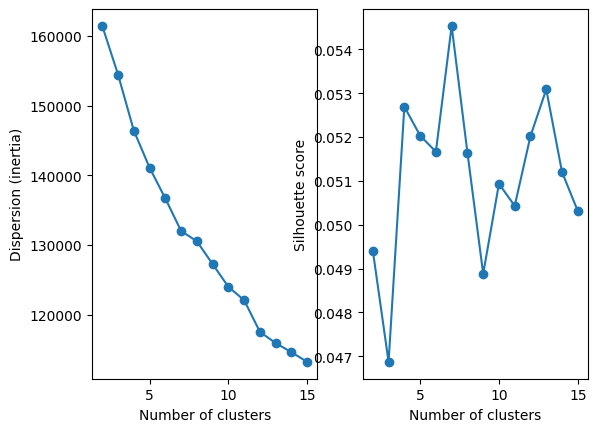

In [152]:
plot_inertia_and_silhouette(behavioral_data_2_st_scl)

In [153]:
kmeans_st_scl = KMeans(n_clusters=2, random_state=42).fit(behavioral_data_2_st_scl)
data_filtered2['st_scaled_km_cluster2'] = kmeans_st_scl.predict(behavioral_data_2_st_scl)
behavioral_data_2['st_scaled_km_cluster2'] = kmeans_st_scl.predict(behavioral_data_2_st_scl)

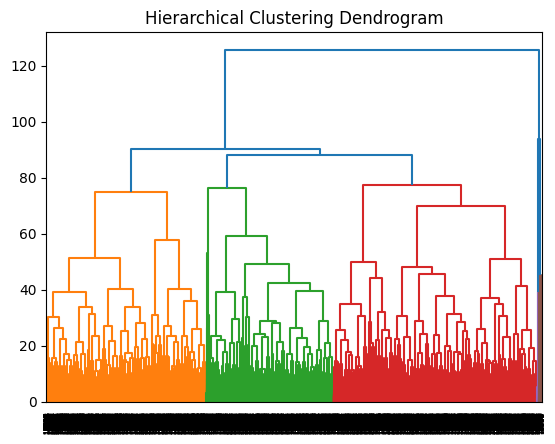

In [154]:
plot_dendrogram(behavioral_data_2_st_scl, 'ward')

In [155]:
data_filtered2['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_st_scl)

behavioral_data_2['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_st_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Min Max Scaling</h3>

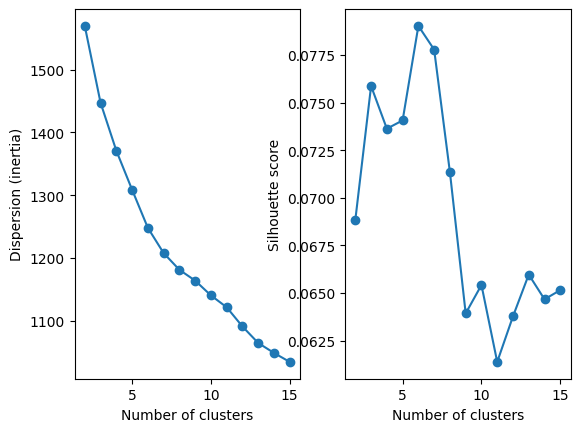

In [156]:
plot_inertia_and_silhouette(behavioral_data_2_mm_scl)

In [157]:
kmeans_mm_scl = KMeans(n_clusters=2, random_state=42).fit(behavioral_data_2_mm_scl)
data_filtered2['mm_scaled_km_cluster2'] = kmeans_mm_scl.predict(behavioral_data_2_mm_scl)
behavioral_data_2['mm_scaled_km_cluster2'] = kmeans_mm_scl.predict(behavioral_data_2_mm_scl)

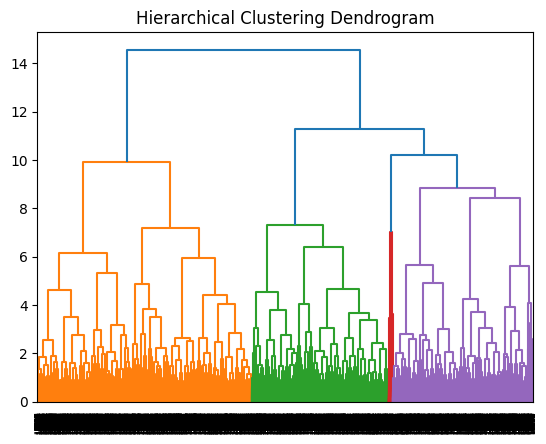

In [158]:
plot_dendrogram(behavioral_data_2_mm_scl, 'ward')

In [159]:
data_filtered2['mm_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_mm_scl)

behavioral_data_2['mm_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_mm_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

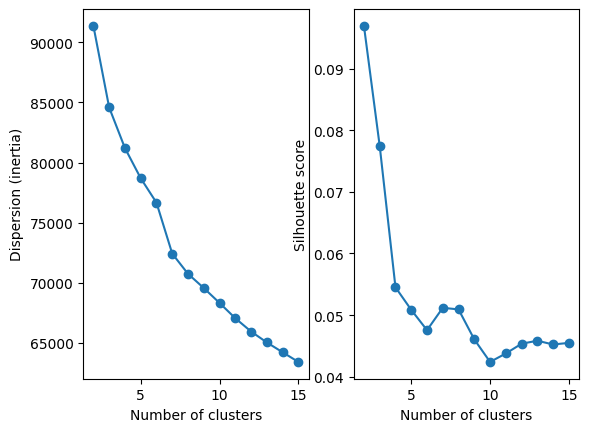

In [160]:
plot_inertia_and_silhouette(behavioral_data_2_rb_scl)

In [161]:
kmeans_rb_scl = KMeans(n_clusters=3, random_state=42).fit(behavioral_data_2_rb_scl)
data_filtered2['rb_scaled_km_cluster3'] = kmeans_rb_scl.predict(behavioral_data_2_rb_scl)
behavioral_data_2['rb_scaled_km_cluster3'] = kmeans_rb_scl.predict(behavioral_data_2_rb_scl)

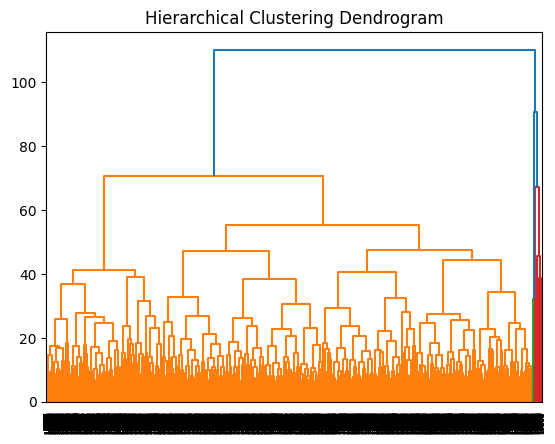

In [162]:
plot_dendrogram(behavioral_data_2_rb_scl, 'ward')

In [163]:
data_filtered2['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_rb_scl)

behavioral_data_2['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_rb_scl)

#### Cluster Visualization 2

In [164]:
cluster_filter1 = ["st_scaled_km_cluster2", "st_scaled_ward_cluster2",
                   'mm_scaled_km_cluster2', "mm_scaled_ward_cluster2",
                   "rb_scaled_km_cluster3", "rb_scaled_ward_cluster2"
                   ]

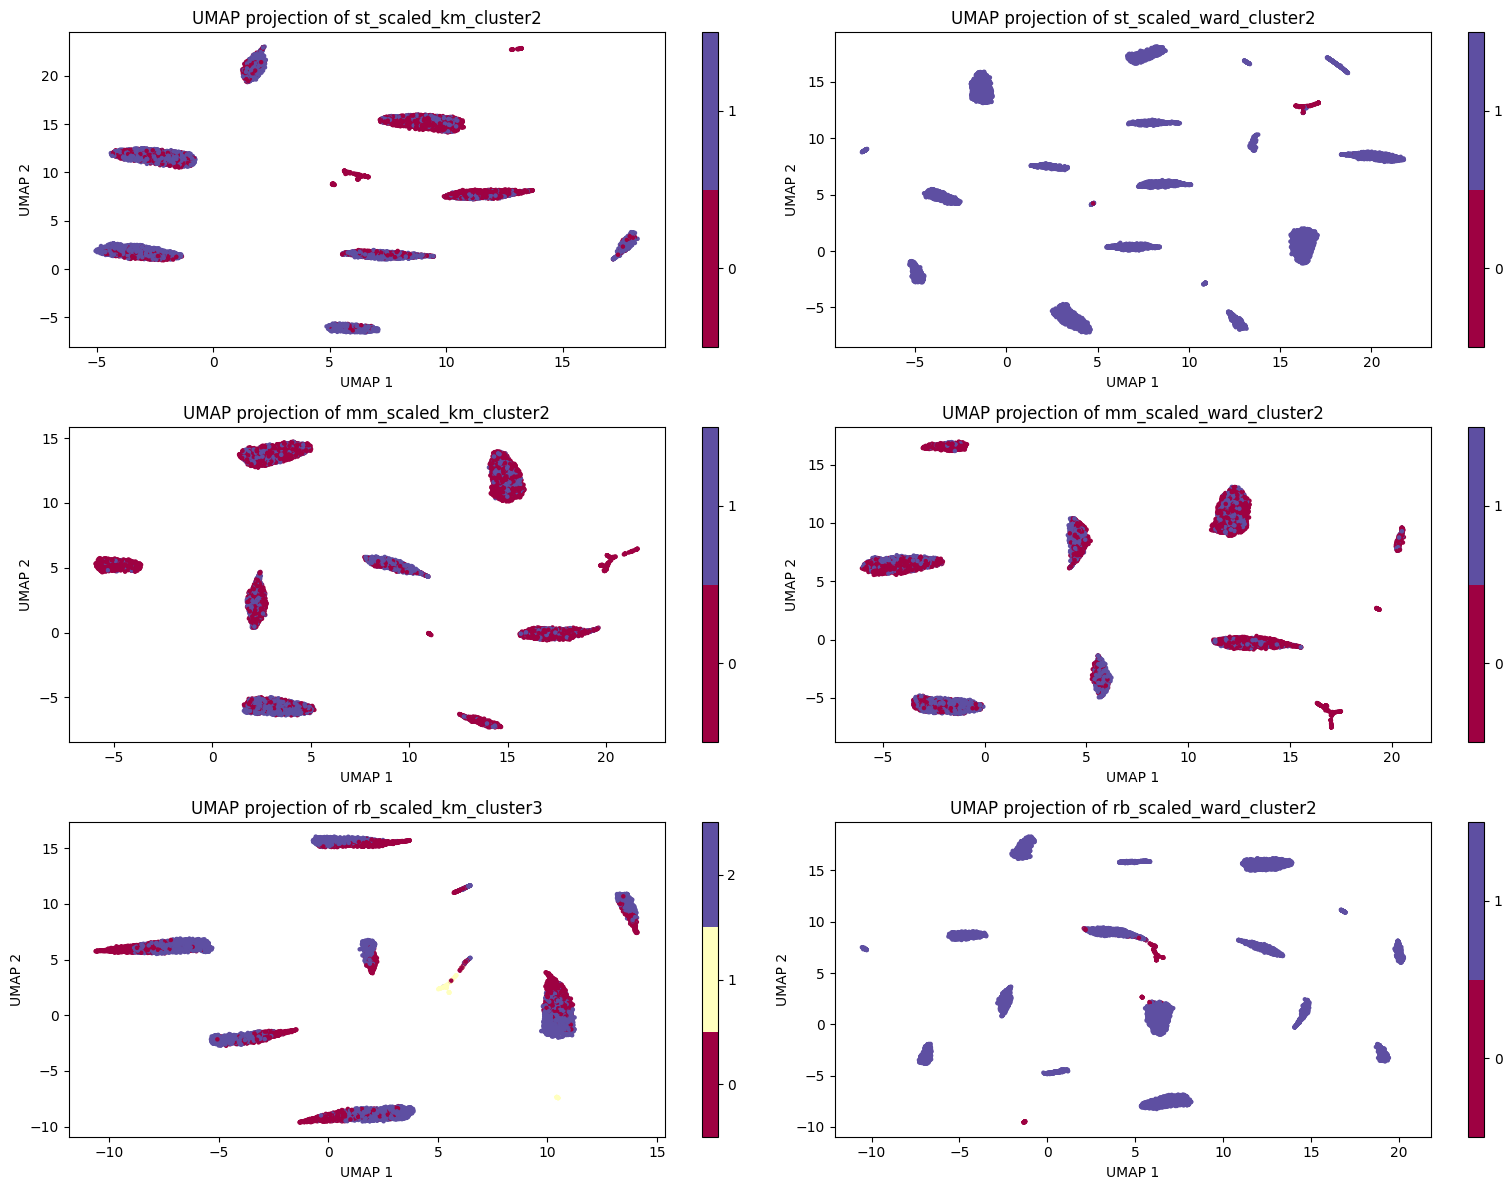

In [165]:
plot_umap_projections(behavioral_data_2, cluster_filter1, n_neighbors= 30, min_dist= 0.1)

In [166]:
groupby_mean(behavioral_data_2, 'rb_scaled_km_cluster3', n_features= 13)

rb_scaled_km_cluster3,0,1,2
PctFlightsWithCompanions,0.322769,0.290325,0.210889
PctPointsSpent,0.521457,0.246345,0.177149
Pct_Spend_Month_1,0.062540,0.506378,0.060347
Pct_Spend_Month_2,0.066874,0.356839,0.059074
Pct_Spend_Month_3,0.085813,0.082663,0.088617
Pct_Spend_Month_4,0.077116,0.031664,0.077047
Pct_Spend_Month_5,0.091765,0.008202,0.089896
Pct_Spend_Month_6,0.102726,0.009757,0.114193
Pct_Spend_Month_7,0.102309,0.001132,0.110669
Pct_Spend_Month_8,0.092708,0.001586,0.092870


Cluster 0 - Active Redeemers with Off-Season Travel

- Active user of rewards (52% points redeemed)

- No Seasonality

Cluster 1 - January and February travelers
 
- 85% of flights on the first two months

Cluster 2 - Holidays travelers

- Fligth peaks at june, july, august and december


#### Cluster Extraction 3 and 4 

In [167]:
# Filter the DataFrame based on cluster labels
active_redeemers = data_filtered2[data_filtered2['rb_scaled_km_cluster3'] == 0]

Jan_Feb_travelers = data_filtered2[data_filtered2['rb_scaled_km_cluster3'] == 1]

holiday_travelers = data_filtered2[data_filtered2['rb_scaled_km_cluster3'] == 2]

In [168]:
# List of cluster labels to exclude
exclude_clusters = [0,1,2]

# Filter the original dataset to exclude rows with specified cluster labels
data_filter3 = data_filtered2[~data_filtered2['rb_scaled_km_cluster3'].isin(exclude_clusters)]

In [169]:
data_filter3

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__4,Location__5,Location__6,Location__7,st_scaled_km_cluster2,st_scaled_ward_cluster2,mm_scaled_km_cluster2,mm_scaled_ward_cluster2,rb_scaled_km_cluster3,rb_scaled_ward_cluster2
Loyalty#,,,,,,,,,,,,,,,,,,,,,


# <span style="color:#0097b2">1. Cluster Extraction</span>
[Back to TOC](#toc)

In the following cell, we'll create a column, called "segment", and give it the name of the cluster in the correspondent rows.

In [170]:
data['segment'] = 'Unassigned'

data.loc[no_activity.index, 'segment'] = 'No_Activity'
data.loc[_8_to_12_travelers.index, 'segment'] = 'August_to_December_travelers'
data.loc[Jan_Feb_travelers.index, 'segment'] = 'Jan_Feb_travelers'
data.loc[active_redeemers.index, 'segment'] = 'Active_Redeemers'
data.loc[holiday_travelers.index, 'segment'] = 'Holiday_travelers'

In [171]:
data['segment'].value_counts()

segment
Holiday_travelers               7420
Active_Redeemers                4599
August_to_December_travelers    3056
No_Activity                     1497
Jan_Feb_travelers                143
Name: count, dtype: int64

Finally, we'll create a binary column to flag each cluster.

In [172]:
segment_dummies = pd.get_dummies(
    data['segment'],
    prefix='seg',
    dtype=int
)

In [173]:
data = pd.concat([data, segment_dummies], axis=1)

In [174]:
data.drop(columns=['segment'], inplace=True)

In [175]:
data = data.loc[:, ~data.columns.str.startswith(("st_", "mm_", "rb_"))]

In [176]:
data

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__3,Location__4,Location__5,Location__6,Location__7,seg_Active_Redeemers,seg_August_to_December_travelers,seg_Holiday_travelers,seg_Jan_Feb_travelers,seg_No_Activity
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0


In [177]:
data.to_csv("../data/behvioral_segment_data.csv")